In [ ]:
#we install lamgchain and its dependencies and architecrure
#pip3 install langchain langgraph langsmith langchain_groq langchain_community  

In [1]:
#create groq api key https://console.groq.com/home
groq_api_key= "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"

In [2]:
from langchain_groq import ChatGroq

In [3]:
llm= ChatGroq(
    # model="groq/llama-3.1-70b-instruct",
    model="gemma2-9b-it",
    api_key=groq_api_key,
    max_retries=3,
    max_tokens=4096,
    temperature=0.7,
)

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END

In [7]:
class State(TypedDict):
    messages: Annotated[list,add_messages]
graph_builder = StateGraph(State)    

In [8]:
graph_builder

In [9]:
def chatbot(state: State):
    return {"message":llm.invoke(state["messages"])}

In [10]:
graph_builder.add_node('chatbot',chatbot)

In [11]:
graph_builder

In [12]:
graph_builder.add_edge(START,'chatbot')
graph_builder.add_edge('chatbot',END)

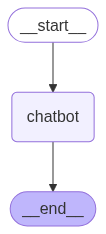

In [13]:
graph_builder.compile()

In [14]:
graph = graph_builder.compile()

In [22]:
while True:
    user_input= input("user: ")
    if user_input.lower() in ["quit", "q"]:
        print("Good bye,Thanks you for using langgraph framework")
        break
    for event in graph.stream({'messages':('user',user_input)}):
        print(event.values())
        for value in event.values():
           print(value['messages'])
   
           

dict_values([None])


TypeError: 'NoneType' object is not subscriptable

In [23]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "q"]:
        print("Goodbye. Thank you for using LangGraph framework.")
        break

    try:
        for event in graph.stream({'messages': ('user', user_input)}):
            print("Event values:", event.values())

            for value in event.values():
                # Safely check if 'messages' exists in value
                if isinstance(value, dict) and 'messages' in value:
                    print(value['messages'])
                else:
                    print("⚠️ 'messages' key not found or value is not a dict.")
                    print("Actual value:", value)
    except Exception as e:
        print("❌ Error:", e)


Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not found or value is not a dict.
Actual value: None
Event values: dict_values([None])
⚠️ 'messages' key not

KeyboardInterrupt: Interrupted by user

In [18]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "q"]:
        print("Goodbye. Thank you for using the LangGraph framework.")
        break

    try:
        for event in graph.stream({'messages': ('user', user_input)}):
            for value in event.values():
                # Optional: print the full value to understand its structure
                # print("Full Value:", value)

                # Safely print messages if key exists
                if 'messages' in value:
                    print("All Messages:", value['messages'])

                # Safely access the assistant's message
                if 'message' in value and 'content' in value['message']:
                    print("Assistant:", value['message']['content'])

        print("End of conversation.")
        print("You can continue the conversation or type 'quit' to exit.\n")

    except Exception as e:
        print("⚠️ Error during conversation:", e)
        continue


⚠️ Error during conversation: argument of type 'NoneType' is not iterable
⚠️ Error during conversation: argument of type 'NoneType' is not iterable
⚠️ Error during conversation: argument of type 'NoneType' is not iterable
⚠️ Error during conversation: argument of type 'NoneType' is not iterable


KeyboardInterrupt: Interrupted by user